# 04c LLM pipeline 2: visualisations to a natural language explanation

Idea: the LLM receives waterfall plots of the SHAP/EBM contributions as an image
and explains what it sees, without structured JSON data.

* Advantage: uses visual pattern recognition, closer to human intuition.
* Disadvantage: precise numbers are lost in the image.

Flow:
1. Generate plots and save them in explanations/plots/ (no API key needed)
2. Send plots plus a context prompt to Claude
3. Save results in results/pipeline05/

In [1]:
from __future__ import annotations

import sys, json, time
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import joblib
import shap

from utils import (
    INSTANCE_IDS,
    EXPLANATIONS_DIR, RESULTS_DIR, MODELS_DIR, PROMPTS_DIR,
)
from utils.data import load_train_test
from utils.llm import ask_with_images, DEFAULT_MODEL, MAX_TOKENS_GENERATION, strip_scratchpad

LOSS_KEY  = 'poisson_log'
MODEL     = DEFAULT_MODEL
MAX_TOKENS = MAX_TOKENS_GENERATION

# n=20 validity run: the 10 instances, 1 generation, real time. Plots and results
# go directly into the main folders (explanations/plots/, results/pipeline05/).
GEN_INSTANCE_IDS = INSTANCE_IDS
N_GEN            = 1
PLOTS_DIR        = EXPLANATIONS_DIR / 'plots'
OUT_DIR          = RESULTS_DIR / 'pipeline05'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'LLM model:     {MODEL}')
print(f'Instances:     {len(GEN_INSTANCE_IDS)} x {N_GEN} generation')
print(f'Plots output:  {PLOTS_DIR}')
print(f'Results:       {OUT_DIR}')

LLM model:     claude-sonnet-4-6
Instances:     10 x 1 generation
Plots output:  /Users/anton/Desktop/SoSe26/Belegarbeit/Implementation-XAI-Stahl-ss26/explanations/plots
Results:       /Users/anton/Desktop/SoSe26/Belegarbeit/Implementation-XAI-Stahl-ss26/results/pipeline05


## 1. Load data and models

In [2]:
X_train, y_train, X_test, y_test = load_train_test()
from utils.models import load_models
xgb, ebm = load_models(LOSS_KEY)

# Initialise the SHAP TreeExplainer once
shap_explainer = shap.TreeExplainer(xgb)
shap_values    = shap_explainer(X_test)

print('Models and SHAP values loaded.')
print(f'X_test shape: {X_test.shape}')

Models and SHAP values loaded.
X_test shape: (5227, 9)


## 2. Plot generation

For each instance and model a waterfall plot is created:
* XGBoost: shap.plots.waterfall (built in)
* EBM: matplotlib bar chart (interpret uses Plotly, not matplotlib)

In [3]:
def plot_xgb_waterfall(instance_id: int) -> Path:
    """SHAP waterfall plot for XGBoost, saved as PNG."""
    pos  = X_test.index.get_loc(instance_id)
    pred = float(xgb.predict(X_test.iloc[[pos]])[0])
    y    = float(y_test.iloc[pos])

    shap.plots.waterfall(shap_values[pos], show=False, max_display=10)
    plt.title(f'XGBoost | instance {instance_id} | '
              f'prediction: {pred:.1f}  (actual: {y:.0f})', pad=12)
    path = PLOTS_DIR / f'waterfall_xgb_{LOSS_KEY}_inst{instance_id}.png'
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.close('all')
    return path


def plot_ebm_waterfall(instance_id: int) -> Path:
    """Manual waterfall plot for the EBM contributions."""
    pos  = X_test.index.get_loc(instance_id)
    inst = X_test.iloc[[pos]]
    pred = float(ebm.predict(inst)[0])
    y    = float(y_test.iloc[pos])

    exp  = ebm.explain_local(inst)
    d    = exp.data(0)
    base = float(d['extra']['scores'][0])  # intercept

    # Main effects only (no interactions), top 10 by absolute score
    pairs = [(n, float(s)) for n, s in zip(d['names'], d['scores'])]
    pairs = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)[:10]
    labels = [p[0] for p in pairs]
    scores = [p[1] for p in pairs]
    colors = ['#d73027' if v > 0 else '#4575b4' for v in scores]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(labels[::-1], scores[::-1], color=colors[::-1], height=0.65)
    ax.axvline(0, color='black', lw=0.8)
    for bar, val in zip(bars, scores[::-1]):
        ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
                f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
    ax.set_xlabel('Contribution (log scale)', fontsize=10)
    ax.set_title(f'EBM | instance {instance_id} | '
                 f'prediction: {pred:.1f}  (actual: {y:.0f})\n'
                 f'Base value (intercept): {base:.3f}', fontsize=11, pad=12)
    plt.tight_layout()
    path = PLOTS_DIR / f'waterfall_ebm_{LOSS_KEY}_inst{instance_id}.png'
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.close('all')
    return path

In [4]:
plot_paths: dict[tuple, Path] = {}

# Plots are deterministic per (model, instance), so 1 plot per unit regardless of
# the number of generations (10 instances x 2 models = 20 plots, no API call).
for n_done, iid in enumerate(GEN_INSTANCE_IDS, 1):
    p_xgb = plot_xgb_waterfall(iid)
    p_ebm = plot_ebm_waterfall(iid)
    plot_paths[('xgb', iid)] = p_xgb
    plot_paths[('ebm', iid)] = p_ebm
    if n_done <= 5 or n_done % 25 == 0:
        print(f'  [{n_done:3d}/{len(GEN_INSTANCE_IDS)}] inst={iid:4d}  to {p_xgb.name} / {p_ebm.name}')

print(f'\n{len(plot_paths)} plots saved in {PLOTS_DIR}')

  [  1/10] inst= 224  to waterfall_xgb_poisson_log_inst224.png / waterfall_ebm_poisson_log_inst224.png
  [  2/10] inst= 580  to waterfall_xgb_poisson_log_inst580.png / waterfall_ebm_poisson_log_inst580.png
  [  3/10] inst=1041  to waterfall_xgb_poisson_log_inst1041.png / waterfall_ebm_poisson_log_inst1041.png
  [  4/10] inst=1481  to waterfall_xgb_poisson_log_inst1481.png / waterfall_ebm_poisson_log_inst1481.png
  [  5/10] inst=1677  to waterfall_xgb_poisson_log_inst1677.png / waterfall_ebm_poisson_log_inst1677.png

20 plots saved in /Users/anton/Desktop/SoSe26/Belegarbeit/Implementation-XAI-Stahl-ss26/explanations/plots


### Methodological limitation: plot resolution as a confound

The plots are saved at dpi=130. A lower faithfulness (RA/SA/VA) of the vision
pipeline compared to JSON to Text is therefore not necessarily inherent to the
visual modality: at dpi=130 the bar labels and feature values can be hard to read
for the LLM, especially for similarly long bars. This overlays the actual modality
effect with a measurement artefact.

Documented as a limitation in results/limitations_vision_resolution.txt. Comparisons
between vision and the other pipelines should be reported with this caveat.

## 3. Show example plots

XGB instance 224:


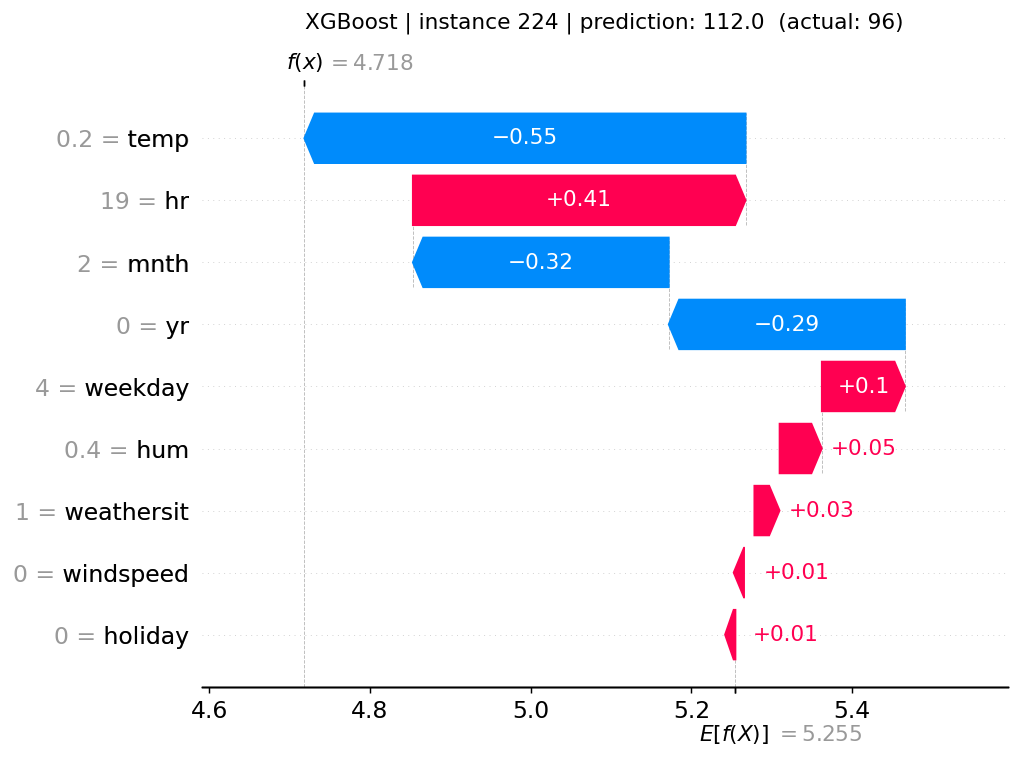


EBM instance 224:


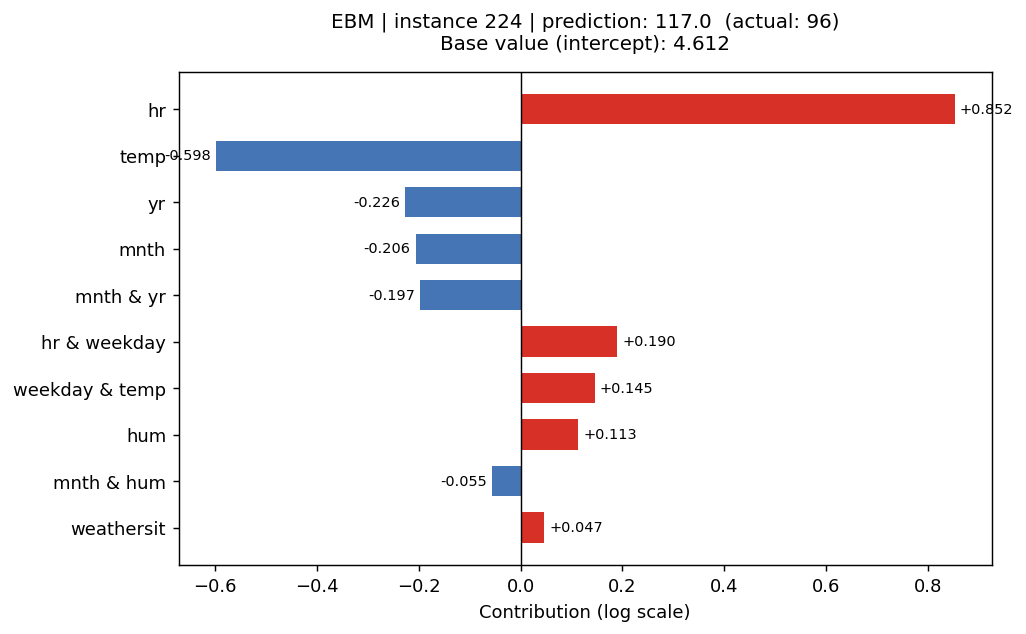

In [5]:
from IPython.display import display, Image as IPImage

for model_name in ['xgb', 'ebm']:
    iid = GEN_INSTANCE_IDS[0]
    print(f'{model_name.upper()} instance {iid}:')
    display(IPImage(filename=str(plot_paths[(model_name, iid)]), width=620))
    print()

## 4. System prompt

In [6]:
SYSTEM_PROMPT = (PROMPTS_DIR / "pipeline_05_vision.md").read_text()

print(f'System prompt: {len(SYSTEM_PROMPT)} characters, ~{len(SYSTEM_PROMPT)//4} tokens (estimated)')

System prompt: 6652 characters, ~1663 tokens (estimated)


## 5. LLM calls with plots

In [7]:
from utils import (
    run_resumable_generation, build_generation_record, load_local_explanation,
)
from utils.llm import build_image_params, run_params
from utils.explanations import (
    WEEKDAY_NAMES, MONTH_NAMES, WEATHER_NAMES,
    TEMP_FACTOR, HUM_FACTOR, WIND_FACTOR,
)

# n=20 validity: real time over the central resume loop. build_context_prompt
# stays visible (the method: which text accompanies the plot). IO loading and the
# record schema come from utils centrally (golden test in test_generation_loop.py).

def build_context_prompt(model_name: str, instance_id: int) -> str:
    """Context text for the plot: readable feature values from the JSON explanation."""
    l = load_local_explanation(model_name, instance_id, loss_key=LOSS_KEY,
                               explanations_dir=EXPLANATIONS_DIR)
    fv = l["feature_values"]
    lines = [
        f"Model: {model_name.upper()}",
        f"Instance ID: {instance_id}",
        f"Time: {int(fv['hr']):02d}:00",
        f"Weekday: {WEEKDAY_NAMES[int(fv['weekday'])]}",
        f"Month: {MONTH_NAMES[int(fv['mnth'])]}",
        f"Year: {'2011' if int(fv['yr']) == 0 else '2012'}",
        f"Weather: {WEATHER_NAMES.get(int(fv['weathersit']), str(fv['weathersit']))}",
        f"Temperature: ~{float(fv['temp']) * TEMP_FACTOR:.1f} C (normalised: {float(fv['temp']):.2f})",
        f"Humidity: {float(fv['hum']) * HUM_FACTOR:.0f} %",
        f"Wind speed: {float(fv['windspeed']) * WIND_FACTOR:.1f} km/h",
        f"Holiday: {'yes' if int(fv['holiday']) == 1 else 'no'}",
        f"Actual rentals: {int(l['y_true'])} bikes",
        f"Model prediction: {l['prediction']:.1f} bikes",
        "",
        "Please explain the waterfall plot above for this situation.",
    ]
    return "\n".join(lines)


def generate_vision(model_name, iid, gen_idx):
    l_exp     = load_local_explanation(model_name, iid, loss_key=LOSS_KEY,
                                       explanations_dir=EXPLANATIONS_DIR)
    plot_path = plot_paths[(model_name, iid)]
    params = build_image_params(
        build_context_prompt(model_name, iid),
        image_paths=[plot_path],
        system=SYSTEM_PROMPT, model=MODEL, max_tokens=MAX_TOKENS, cache_system=True,
    )
    t0 = time.time()
    response = run_params(params)
    elapsed  = time.time() - t0

    text  = strip_scratchpad(response["content"][0]["text"])
    usage = response.get("usage", {})
    record = build_generation_record(
        pipeline="05_vision", model_name=model_name, instance_id=iid,
        explanation=text, usage=usage, llm_model=MODEL, loss_key=LOSS_KEY,
        prediction=l_exp["prediction"], y_true=l_exp["y_true"],
        elapsed_s=round(elapsed, 2), extra={"plot_file": plot_path.name},
    )
    u = record["usage"]
    print(f"  {model_name.upper()} inst={iid:4d} g{gen_idx}  "
          f"pred={record['prediction']:6.1f}  y={record['y_true']:5.0f}  "
          f"in={u['input_tokens']}  out={u['output_tokens']}  "
          f"cache={u['cache_read_input_tokens']}  t={elapsed:.1f}s")
    return record


results = run_resumable_generation(
    model_names=["xgb", "ebm"],
    instance_ids=GEN_INSTANCE_IDS,
    out_dir=OUT_DIR,
    generate=generate_vision,
    n_generations=N_GEN,
)

totals = {
    "in":    sum(r["usage"]["input_tokens"] for r in results),
    "out":   sum(r["usage"]["output_tokens"] for r in results),
    "cache": sum(r["usage"]["cache_read_input_tokens"] for r in results),
}
print(f"\nTotal:  input={totals['in']}  output={totals['out']}  "
      f"cache_read={totals['cache']}  ({len(results)} units)")

  XGB inst= 224 g0  pred= 112.0  y=   96  in=1159  out=589  cache=0  t=13.4s
  XGB inst= 580 g0  pred=  64.6  y=   63  in=1159  out=535  cache=1845  t=12.7s
  XGB inst=1041 g0  pred= 385.4  y=  387  in=1217  out=555  cache=1845  t=12.8s
  XGB inst=1481 g0  pred= 228.6  y=  277  in=1216  out=557  cache=1845  t=12.8s
  XGB inst=1677 g0  pred= 254.3  y=  286  in=1217  out=573  cache=1845  t=13.0s
  XGB inst=2058 g0  pred= 194.1  y=  243  in=1160  out=598  cache=1845  t=13.2s
  XGB inst=2510 g0  pred= 326.0  y=  372  in=1160  out=549  cache=1845  t=12.1s
  XGB inst=3543 g0  pred= 309.9  y=  286  in=1216  out=578  cache=1845  t=13.9s
  XGB inst=3847 g0  pred= 585.8  y=  531  in=1216  out=547  cache=1845  t=12.5s
  XGB inst=4454 g0  pred= 297.3  y=  354  in=1217  out=552  cache=1845  t=12.5s
  EBM inst= 224 g0  pred= 117.0  y=   96  in=975  out=612  cache=1845  t=15.9s
  EBM inst= 580 g0  pred=  73.1  y=   63  in=975  out=582  cache=1845  t=14.2s
  EBM inst=1041 g0  pred= 389.7  y=  387  in=

## 6. Example explanations

In [8]:
for rec in results[:2]:
    sep = '=' * 70
    print(sep)
    print(f"Model: {rec['xai_model'].upper()}  |  instance: {rec['instance_id']}  "
          f"|  plot: {rec['plot_file']}")
    print(f"Prediction: {rec['prediction']:.1f}  |  actual: {rec['y_true']:.0f}")
    print(sep)
    print(rec['explanation'])
    print()

Model: XGB  |  instance: 224  |  plot: waterfall_xgb_poisson_log_inst224.png
Prediction: 112.0  |  actual: 96
<prediction>The XGBoost model predicted 112 rented bikes for this hour, while the actual count was 96. The model overshot by about 16 bikes, which is a moderate mismatch of roughly 17 percent — a reasonable but not excellent result.</prediction>

<drivers>The strongest single influence is temperature: at only about 8 °C (normalised 0.20), the cold weather is the largest damping factor, pulling the prediction down by 0.55. Despite this, the hour of day (hr=19, evening peak) pushes strongly upward with a contribution of +0.41 — Thursday at 7 pm is prime commuter return time, and the model recognises this clearly. February (mnth=2) adds a second damping effect at −0.32, reflecting the low winter demand typical of that month. The year 2011 (yr=0) also carries a blue bar at −0.29, meaning 2011 was the lower-demand phase of the system's history, further reducing the baseline. On the 

## 7. Summary

In [9]:
import pandas as pd

summary = pd.DataFrame([
    {
        'Model':      r['xai_model'].upper(),
        'Instance':   r['instance_id'],
        'y_true':     r['y_true'],
        'Prediction': r['prediction'],
        'Words':      len(r['explanation'].split()),
        'tok_input':  r['usage']['input_tokens'],
        'tok_output': r['usage']['output_tokens'],
        'Time (s)':   r['elapsed_s'],
    }
    for r in results
])
display(summary)

,Model,Instance,y_true,Prediction,Words,tok_input,tok_output,Time (s)
0,XGB,224,96.0,111.9967,245,1159,589,13.37
1,XGB,580,63.0,64.5773,216,1159,535,12.67
2,XGB,1041,387.0,385.3899,222,1217,555,12.80
3,XGB,1481,277.0,228.5813,233,1216,557,12.79
4,XGB,1677,286.0,254.2623,248,1217,573,12.97
5,XGB,2058,243.0,194.0592,261,1160,598,13.22
6,XGB,2510,372.0,326.0351,223,1160,549,12.14
7,XGB,3543,286.0,309.9225,238,1216,578,13.89
8,XGB,3847,531.0,585.7666,218,1216,547,12.46
9,XGB,4454,354.0,297.3312,239,1217,552,12.51
